<a href="https://colab.research.google.com/github/wiz124/chem169-git/blob/main/Li_Harry_RID_37F_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Exercise 1
!unzip student_materials.zip


Archive:  student_materials.zip
replace pools/Pool_C/job_input.json? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
#Exercise 1
import json
import numpy as np
import pandas as pd

POOLS=['Pool_A','Pool_B','Pool_C','Pool_D','Pool_E','Pool_F','Pool_G',
       'Pool_H','Pool_I']
SCORES={}
proteindf=pd.read_csv('protein_info.csv')

def parse_pool(pool_name: str,
               json_path,
               pool_chains: pd.DataFrame) -> list[dict]:
  with open(json_path) as f:
        data = json.load(f)
  iptm    = np.array(data["chain_pair_iptm"])     # shape (n, n)
  pae_min = np.array(data["chain_pair_pae_min"])

  n = len(pool_chains)
  # if iptm.shape != (n, n):
  #       print(f"  WARNING: matrix shape {iptm.shape} != expected ({n},{n}) "
  #             f"for pool '{pool_name}' — skipping.")
  #       return []

  records = []
  for i in range(n):
        for j in range(i + 1, n):
            try:
              row_i = pool_chains.iloc[i]
              row_j = pool_chains.iloc[j]

              records.append({
                  "pool":      pool_name,
                  "chain_i":   i,
                  "chain_j":   j,
                  "protein_i": row_i["protein_id"],
                  "protein_j": row_j["protein_id"],
                  "len_i":     int(row_i["length"]),
                  "len_j":     int(row_j["length"]),
                  # ipTM is symmetric — one value suffices
                  "iptm":      round(float(iptm[i, j]), 4),
                  # PAE is directional — take the more confident (lower) direction
                  "min_pae":   round(float(min(pae_min[i, j], pae_min[j, i])), 4),
              })
            except:
              continue

  return records

all_records = []
#Parse confidence scores from each pool
for folder in POOLS:
  pool_chains = (proteindf[proteindf["pool"] == folder]
               .sort_values("chain_idx")
               .reset_index(drop=True))

  records = parse_pool(folder, f'pools/{folder}/summary_confidences_0.json', pool_chains)

  all_records.extend(records)

df = pd.DataFrame(all_records, columns=[
    "pool", "chain_i", "chain_j",
    "protein_i", "protein_j",
    "len_i", "len_j",
    "iptm", "min_pae",
])
display(df)

,pool,chain_i,chain_j,protein_i,protein_j,len_i,len_j,iptm,min_pae
0,Pool_A,0,1,b2283,b2286,908,596,0.82,1.76
1,Pool_A,0,2,b2283,b1570,908,135,0.11,31.03
2,Pool_A,0,3,b2283,b2354,908,146,0.13,27.99
3,Pool_A,0,4,b2283,b2594,908,326,0.18,24.30
4,Pool_A,0,5,b2283,b4062,908,107,0.11,30.46
...,...,...,...,...,...,...,...,...,...
400,Pool_I,6,8,b3661,b4555,272,97,0.05,30.47
401,Pool_I,6,9,b3661,b3293,272,122,0.05,31.47
402,Pool_I,7,8,b1368,b4555,342,97,0.06,30.26
403,Pool_I,7,9,b1368,b3293,342,122,0.07,28.83


In [ ]:
#Exercise 2
corrected_iptm=[]
for idx,iptm in enumerate(df['iptm']):
  len_a=df.iloc[idx]['len_i']
  len_b=df.iloc[idx]['len_j']

  size_corrected_iptm = iptm - (0.0044 * np.sqrt(len_a + len_b) - 0.036)
  corrected_iptm.append(size_corrected_iptm)

df['corrected_iptm']=corrected_iptm
display(df)

,pool,chain_i,chain_j,protein_i,protein_j,len_i,len_j,iptm,min_pae,corrected_iptm
0,Pool_A,0,1,b2283,b2286,908,596,0.82,1.76,0.685362
1,Pool_A,0,2,b2283,b1570,908,135,0.11,31.03,0.003900
2,Pool_A,0,3,b2283,b2354,908,146,0.13,27.99,0.023152
3,Pool_A,0,4,b2283,b2594,908,326,0.18,24.30,0.061435
4,Pool_A,0,5,b2283,b4062,908,107,0.11,30.46,0.005820
...,...,...,...,...,...,...,...,...,...,...
400,Pool_I,6,8,b3661,b4555,272,97,0.05,30.47,0.001479
401,Pool_I,6,9,b3661,b3293,272,122,0.05,31.47,-0.001338
402,Pool_I,7,8,b1368,b4555,342,97,0.06,30.26,0.003810
403,Pool_I,7,9,b1368,b3293,342,122,0.07,28.83,0.011221


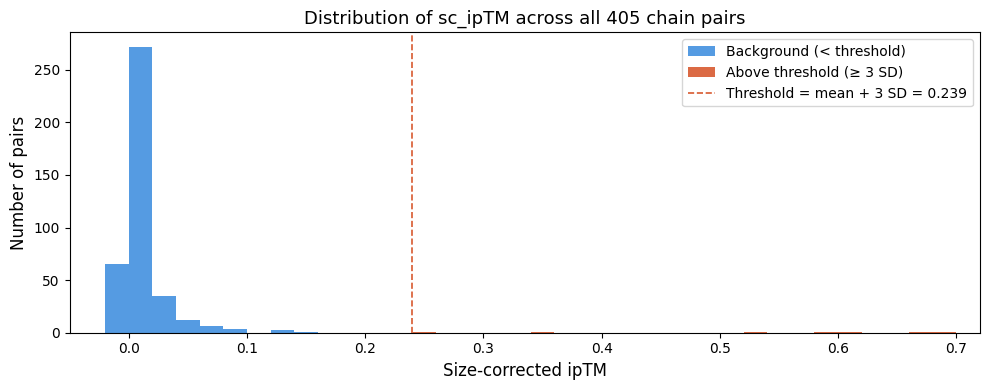

Top pair per pool:


,Pool,Contains PPI?,Top sc_ipTM,Top min_PAE,Justification
0,Pool_A,Yes,0.6854,1.76,34× above background mean; 9.1 SD above mean; ...
1,Pool_B,Yes,0.6664,3.70,33× above background mean; 8.8 SD above mean; ...
2,Pool_C,Yes,0.6128,3.46,30× above background mean; 8.1 SD above mean; ...
3,Pool_D,Yes,0.5978,4.22,30× above background mean; 7.9 SD above mean; ...
4,Pool_E,Yes,0.5304,6.66,26× above background mean; 7.0 SD above mean; ...
5,Pool_F,No,0.0796,17.08,sc_ipTM = 0.080 within background; min_PAE = 1...
6,Pool_G,No,0.0908,24.58,sc_ipTM = 0.091 within background; min_PAE = 2...
7,Pool_H,Yes,0.2522,9.48,13× above background mean; 3.2 SD above mean; ...
8,Pool_I,No,0.0509,23.49,sc_ipTM = 0.051 within background; min_PAE = 2...


In [ ]:
#Exercise 3 Part 1
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

def justify(row, thresh, bg_mean, bg_std):
    sc   = row["corrected_iptm"]
    pae  = row["min_pae"]
    fold = sc / bg_mean if bg_mean > 0 else 0
    sds  = (sc - bg_mean) / bg_std

    if sc >= thresh and pae < 15:
        return ("Yes",
                f"{fold:.0f}× above background mean; "
                f"{sds:.1f} SD above mean; "
                f"min_PAE = {pae:.2f} corroborates")
    elif sc >= thresh and pae >= 15:
        return ("No",
                f"Marginally above threshold ({sc:.3f}) but "
                f"min_PAE = {pae:.1f} provides no corroboration")
    else:
        return ("No",
                f"sc_ipTM = {sc:.3f} within background; "
                f"min_PAE = {pae:.1f} — no signal")


sc = df["corrected_iptm"]

bg_mean = sc.mean()
bg_std  = sc.std()
thresh  = bg_mean + 3 * bg_std

fig, ax = plt.subplots(figsize=(10, 4))

bins = np.arange(-0.02, 0.72, 0.02)
vals = sc.values

# Split into background vs signal for colouring
bg_vals  = vals[vals <  thresh]
sig_vals = vals[vals >= thresh]

ax.hist(bg_vals,  bins=bins, color="#378ADD", alpha=0.85, label="Background (< threshold)")
ax.hist(sig_vals, bins=bins, color="#D85A30", alpha=0.90, label="Above threshold (≥ 3 SD)")

ax.axvline(thresh, color="#D85A30", linestyle="--", linewidth=1.2,
           label=f"Threshold = mean + 3 SD = {thresh:.3f}")

ax.set_xlabel("Size-corrected ipTM", fontsize=12)
ax.set_ylabel("Number of pairs", fontsize=12)
ax.set_title("Distribution of sc_ipTM across all 405 chain pairs", fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(-0.05, 0.72)
plt.tight_layout()
plt.show()

top_pairs = (
    df.loc[df.groupby("pool")["corrected_iptm"].idxmax()]
    .sort_values("pool")
    .reset_index(drop=True)
)
print("Top pair per pool:")
top_pairs[["pool", "protein_i", "protein_j",
           "len_i", "len_j", "iptm", "corrected_iptm", "min_pae"]]


results = []
for _, row in top_pairs.iterrows():
    decision, justification = justify(row, thresh, bg_mean, bg_std)
    results.append({
        "Pool":          row["pool"],
        "Contains PPI?": decision,
        "Top sc_ipTM":   round(row["corrected_iptm"], 4),
        "Top min_PAE":   round(row["min_pae"], 2),
        "Justification": justification,
    })

classification = pd.DataFrame(results)
display(classification)


PPI-positive pools: ['Pool_A', 'Pool_B', 'Pool_C', 'Pool_D', 'Pool_E', 'Pool_H']



,Pool,Interacting pair,len_i (aa),len_j (aa),raw_ipTM,sc_ipTM,min_PAE
0,Pool_A,b2283 + b2286,908,596,0.82,0.685362,1.76
1,Pool_B,b0902 + b0903,246,760,0.77,0.666443,3.70
2,Pool_C,b3454 + b3456,237,425,0.69,0.612791,3.46
3,Pool_D,b0588 + b0590,271,334,0.67,0.597774,4.22
4,Pool_E,b3725 + b3727,257,319,0.60,0.530400,6.66
5,Pool_H,b4085 + b0644,231,325,0.32,0.252250,9.48


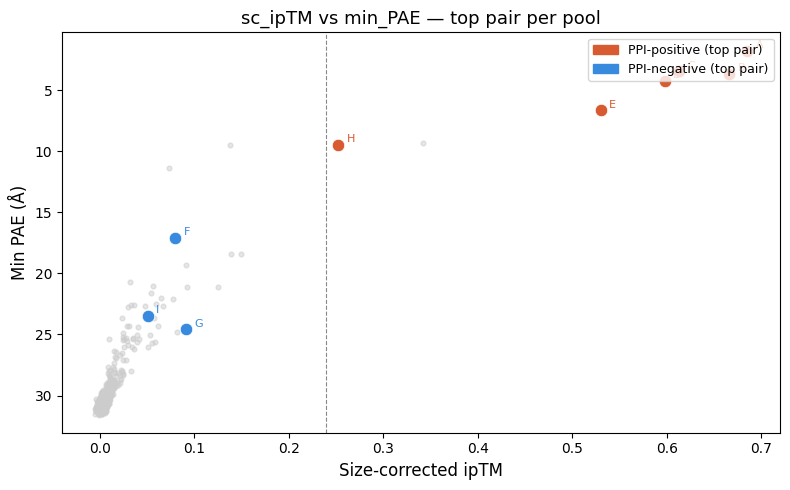


Summary: 6 PPI-positive pools out of 9
Positive pools: Pool_A, Pool_B, Pool_C, Pool_D, Pool_E, Pool_H


In [ ]:
#Exercise 3 Part 2
positive_pools = classification.loc[
    classification["Contains PPI?"] == "Yes", "Pool"
].tolist()

print(f"PPI-positive pools: {positive_pools}\n")

pos_top = top_pairs[top_pairs["pool"].isin(positive_pools)].copy()
pos_top["Interacting pair"] = pos_top["protein_i"] + " + " + pos_top["protein_j"]

pairs_table = pos_top[[
    "pool", "Interacting pair",
    "len_i", "len_j",
    "iptm", "corrected_iptm", "min_pae"
]].rename(columns={
    "pool":           "Pool",
    "len_i":          "len_i (aa)",
    "len_j":          "len_j (aa)",
    "iptm":           "raw_ipTM",
    "corrected_iptm": "sc_ipTM",
    "min_pae":        "min_PAE",
}).reset_index(drop=True)

display(pairs_table)

fig, ax = plt.subplots(figsize=(8, 5))

# Plot all 405 pairs as grey background
ax.scatter(df["corrected_iptm"], df["min_pae"],
           color="#cccccc", s=12, alpha=0.5, zorder=1, label="All pairs")

# Highlight top pair per pool, coloured by classification
for _, row in top_pairs.iterrows():
    is_pos = row["pool"] in positive_pools
    color  = "#D85A30" if is_pos else "#378ADD"
    ax.scatter(row["corrected_iptm"], row["min_pae"],
               color=color, s=80, zorder=3, edgecolors="white", linewidths=0.5)
    ax.annotate(
        row["pool"].replace("Pool_", ""),
        (row["corrected_iptm"], row["min_pae"]),
        xytext=(6, 2), textcoords="offset points",
        fontsize=8, color=color
    )

# Threshold line
ax.axvline(thresh, color="#888", linestyle="--", linewidth=0.8,
           label=f"sc_ipTM threshold = {thresh:.3f}")

pos_patch = mpatches.Patch(color="#D85A30", label="PPI-positive (top pair)")
neg_patch = mpatches.Patch(color="#378ADD", label="PPI-negative (top pair)")
ax.legend(handles=[pos_patch, neg_patch], fontsize=9, loc="upper right")

ax.set_xlabel("Size-corrected ipTM", fontsize=12)
ax.set_ylabel("Min PAE (Å)", fontsize=12)
ax.set_title("sc_ipTM vs min_PAE — top pair per pool", fontsize=13)
ax.invert_yaxis()    # lower PAE = more confident = higher on plot
plt.tight_layout()
plt.show()

print(f"\nSummary: {len(positive_pools)} PPI-positive pools out of {df['pool'].nunique()}")
print(f"Positive pools: {', '.join(positive_pools)}")

#Exercise 3
Q1: Pools A, B, C, D, E, H stand as clearly hinting towards protein protein interactions

Q2: The maximum corrected_iptm score for each pool's top pair exceeds 3 standard deviations from the mean.

Part 2:

What stands out from the background?

There is a small set of clusters completely detached from the left side cluster

How does min_PAE complement sc_ipTM?

min_PAE helps determine positional uncertainty of the chains in relation to each other. High PAE means that Alphafold has no idea where the chains are in relation to each other. This complements sc_iptm by indicating the uncertainty in positioning if the chains are predicted to interact.


In [ ]:
#Exercise 4
POSITIONS = {
    1: (35,  8),
    2: (31,  4),
    3: (55, 10),
    4: ( 6, 114),
    5: ( 5, 16),
}
seq_lookup = dict(zip(proteindf["protein_id"], proteindf["sequence"]))

bg_mean = df["corrected_iptm"].mean()
bg_std  = df["corrected_iptm"].std()
thresh  = bg_mean + 3 * bg_std

# Top pair per pool
top_pairs = (
    df.loc[df.groupby("pool")["corrected_iptm"].idxmax()]
    .sort_values("pool")
    .reset_index(drop=True)
)

# Filter to positive pools, ranked highest → lowest sc_ipTM, take top 5
ranked = (
    top_pairs[top_pairs["corrected_iptm"] >= thresh]
    .sort_values("corrected_iptm", ascending=False)
    .head(5)
    .reset_index(drop=True)
)
ranked.index += 1   # 1-based rank

ranked[["pool", "protein_i", "protein_j", "corrected_iptm", "min_pae"]]
for rank, row in ranked.iterrows():
    pool_chains = (
        proteindf[proteindf["pool"] == row["pool"]]
        .sort_values("chain_idx")
        [["chain_idx", "protein_id"]]
    )
    pi = pool_chains[pool_chains["protein_id"] == row["protein_i"]]["chain_idx"].values[0]
    pj = pool_chains[pool_chains["protein_id"] == row["protein_j"]]["chain_idx"].values[0]
    print(f"  Rank {rank} ({row['pool']}): "
          f"{row['protein_i']} chain_idx={pi} [protein_i]  "
          f"{row['protein_j']} chain_idx={pj} [protein_j]")

    assert pi < pj, f"Orientation error in {row['pool']}!"
print(f"{'Rank':<6} {'Pool':<8} {'protein_i':<10} {'pos_i':<7} {'aa_i':<6} "
      f"{'protein_j':<10} {'pos_j':<7} {'aa_j'}")
print("-" * 65)

message = []
for rank, row in ranked.iterrows():
    pos_i, pos_j = POSITIONS[rank]
    seq_i = seq_lookup[row["protein_i"]]
    seq_j = seq_lookup[row["protein_j"]]
    aa_i  = seq_i[pos_i - 1]   # convert 1-based to 0-based
    aa_j  = seq_j[pos_j - 1]
    message += [aa_i, aa_j]
    print(f"{rank:<6} {row['pool']:<8} {row['protein_i']:<10} {pos_i:<7} {aa_i:<6} "
          f"{row['protein_j']:<10} {pos_j:<7} {aa_j}")

print()
print(f"Decoded message: {''.join(message)}")

  Rank 1 (Pool_A): b2283 chain_idx=0 [protein_i]  b2286 chain_idx=1 [protein_j]
  Rank 2 (Pool_B): b0902 chain_idx=0 [protein_i]  b0903 chain_idx=1 [protein_j]
  Rank 3 (Pool_C): b3454 chain_idx=0 [protein_i]  b3456 chain_idx=1 [protein_j]
  Rank 4 (Pool_D): b0588 chain_idx=0 [protein_i]  b0590 chain_idx=1 [protein_j]
  Rank 5 (Pool_E): b3725 chain_idx=0 [protein_i]  b3727 chain_idx=1 [protein_j]
Rank   Pool     protein_i  pos_i   aa_i   protein_j  pos_j   aa_j
-----------------------------------------------------------------
1      Pool_A   b2283      35      W      b2286      8       E
2      Pool_B   b0902      31      L      b0903      4       L
3      Pool_C   b3454      55      P      b3456      10      L
4      Pool_D   b0588      6       A      b0590      114     Y
5      Pool_E   b3725      5       E      b3727      16      D

Decoded message: WELLPLAYED


Analysis:

The approach I took was using size corrected iptm and min_PAE to help determine interacting protein pairs. I size corrected because raw ipTM can be high due to protein just being big. A threshold of mean + 3 SD (~0.089) was used to flag outliers. The background distribution of all 405 sc_ipTM values was used as a reference, with non interacting pairs defining noise. To identify positive PPI, pairs with high sc_ipTM and low min_PAE were identified since high sc_ipTM suggested interaction and low min_PAE suggested interaction confidence.
